In [1]:
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix
import torchvision.transforms.functional as TF
import pandas as pd, random

In [2]:
TRAIN_FILE  = 'quickdraw_train.npz'
TEST_FILE   = 'quickdraw_test.npz'
BATCH_SIZE  = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available()
                  else 'mps'  if torch.backends.mps.is_available()
                  else 'cpu')
CLASSES = ['apple','baseballbat','basketball','clock','compass',
           'cookie','donut','ladder','mountain','pizza',
           'rabbit','soccerball','spider','t-shirt','wheel']
NUM_CLASSES = 15
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        self.mode = mode
        data = np.load(file_path)
        if mode == 'train':
            self.x = torch.from_numpy(data['x_train']).float().reshape(-1, 28, 28) / 255.0
            self.y = torch.from_numpy(data['y_train']).long()
        else:
            self.x = torch.from_numpy(data['test_images']).float().reshape(-1, 28, 28) / 255.0
            self.y = None
        print(f'Loaded {len(self.x)} {mode} samples')

    def __len__(self): return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx].unsqueeze(0)
        if self.y is not None:
            return img, self.y[idx]
        return img

full_ds = QuickDrawDataset(TRAIN_FILE, mode='train')
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {n_train:,} | Val: {n_val:,}')

Loaded 60000 train samples
Train: 48,000 | Val: 12,000


In [4]:
class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 15)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

pancake = PancakeMLP()
print(f'Pancake parameters: {sum(p.numel() for p in pancake.parameters()):,}')

Pancake parameters: 1,868,815


In [5]:
def train_simple(model, epochs, lr, label):
    model = model.to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss()
    hist  = {'ta': [], 'va': [], 'tl': [], 'vl': []}
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out  = model(X)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            tl += loss.item() * X.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += X.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out  = model(X)
                vl  += crit(out, y).item() * X.size(0)
                vc  += (out.argmax(1) == y).sum().item()
                vt  += X.size(0)

        ta, va = tc/tt, vc/vt
        hist['tl'].append(tl/tt); hist['vl'].append(vl/vt)
        hist['ta'].append(ta);    hist['va'].append(va)

        if va > best_acc:
            best_acc   = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if ep % 5 == 0 or ep == 1:
            print(f'[{label}] Ep {ep:2d}/{epochs}  Train {ta:.4f}  Val {va:.4f}  (best {best_acc:.4f})')

    model.load_state_dict(best_state)
    print(f'\n[{label}] Best Val Acc: {best_acc:.4f}')
    return model, hist, best_acc


def plot_history(hist, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(hist['tl'], label='Train'); a1.plot(hist['vl'], label='Val')
    a1.set_title(f'{title} - Loss'); a1.legend(); a1.set_xlabel('Epoch')
    a2.plot(hist['ta'], label='Train'); a2.plot(hist['va'], label='Val')
    a2.set_title(f'{title} - Accuracy'); a2.legend(); a2.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=100)
    plt.show()

[Pancake] Ep  1/20  Train 0.6130  Val 0.6951  (best 0.6951)
[Pancake] Ep  5/20  Train 0.8406  Val 0.7492  (best 0.7543)
[Pancake] Ep 10/20  Train 0.9480  Val 0.7612  (best 0.7648)
[Pancake] Ep 15/20  Train 0.9812  Val 0.7516  (best 0.7648)
[Pancake] Ep 20/20  Train 0.9824  Val 0.7475  (best 0.7648)

[Pancake] Best Val Acc: 0.7648


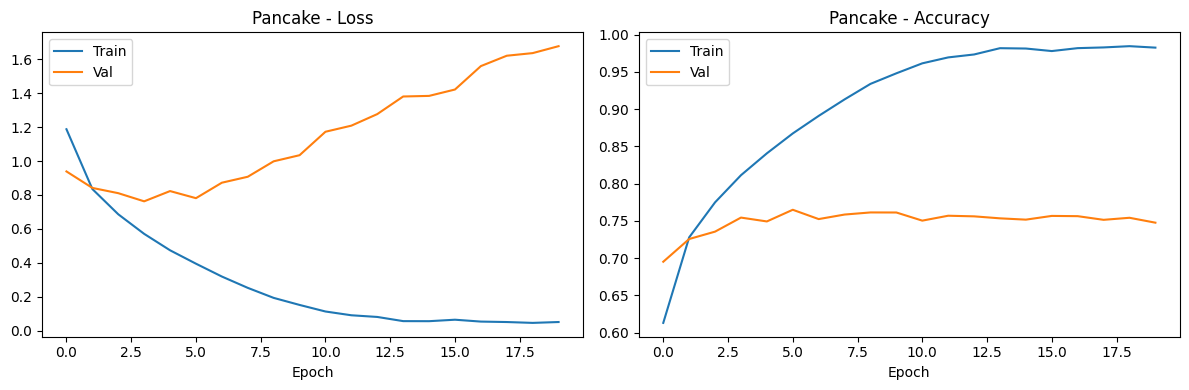

In [6]:
PANCAKE_EPOCHS = 20
pancake, ph, pancake_val = train_simple(pancake, epochs=PANCAKE_EPOCHS, lr=1e-3, label='Pancake')
plot_history(ph, 'Pancake')
torch.save(pancake.state_dict(), 'pancake_weights.pth')

In [7]:
class TowerMLP(nn.Module):
    def __init__(self, hidden=128, depth=8):
        super().__init__()
        layers = []
        in_f = 784
        for _ in range(depth):
            layers.append(nn.Linear(in_f, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            in_f = hidden
        layers.append(nn.Linear(hidden, 15))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

tower = TowerMLP()
print(f'Tower parameters: {sum(p.numel() for p in tower.parameters()):,}')

Tower parameters: 220,047


[Tower] Ep  1/25  Train 0.5510  Val 0.6789  (best 0.6789)
[Tower] Ep  5/25  Train 0.7957  Val 0.7262  (best 0.7262)
[Tower] Ep 10/25  Train 0.8649  Val 0.7328  (best 0.7398)
[Tower] Ep 15/25  Train 0.9034  Val 0.7338  (best 0.7398)
[Tower] Ep 20/25  Train 0.9319  Val 0.7298  (best 0.7398)
[Tower] Ep 25/25  Train 0.9450  Val 0.7337  (best 0.7398)

[Tower] Best Val Acc: 0.7398


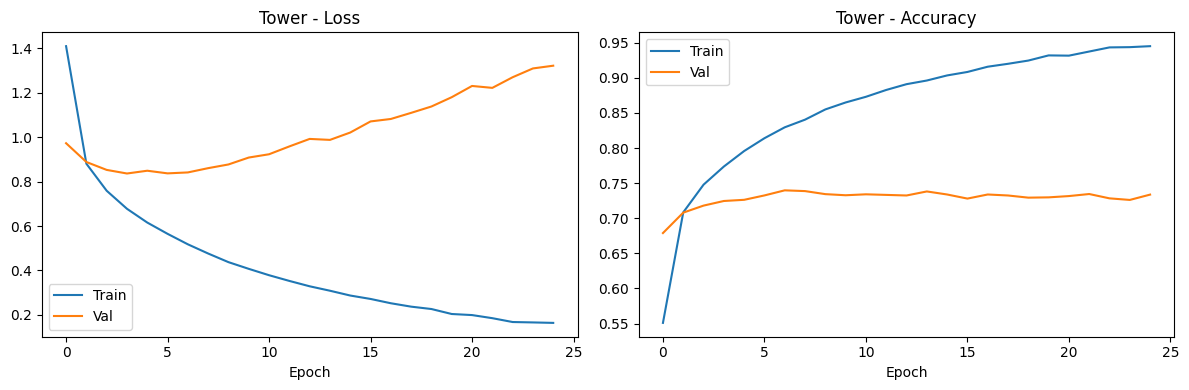

In [8]:
TOWER_EPOCHS = 25
tower, th, tower_val = train_simple(tower, epochs=TOWER_EPOCHS, lr=5e-4, label='Tower')
plot_history(th, 'Tower')
torch.save(tower.state_dict(), 'tower_weights.pth')

In [9]:
def augment_batch(X):
    out = X.clone()
    for i in range(out.size(0)):
        img = out[i]
        if random.random() > 0.5:
            img = TF.hflip(img)
        img = TF.rotate(img, random.uniform(-15, 15))
        if random.random() > 0.5:
            tx = random.uniform(-0.10, 0.10) * 28
            ty = random.uniform(-0.10, 0.10) * 28
            img = TF.affine(img, angle=0, translate=[tx, ty], scale=1.0, shear=0)
        if random.random() < 0.3:
            x0 = random.randint(0, 20); y0 = random.randint(0, 20)
            w  = random.randint(3, 8);  h  = random.randint(3, 8)
            img[:, y0:y0+h, x0:x0+w] = 0.0
        out[i] = img
    return out


def mixup_batch(X, y, alpha=0.3):
    lam   = float(np.random.beta(alpha, alpha))
    lam   = max(lam, 1 - lam)
    idx   = torch.randperm(X.size(0), device=X.device)
    X_mix = lam * X + (1 - lam) * X[idx]
    y_a   = F.one_hot(y, NUM_CLASSES).float()
    y_b   = F.one_hot(y[idx], NUM_CLASSES).float()
    return X_mix, lam * y_a + (1 - lam) * y_b

def soft_ce(logits, soft_y):
    return -(soft_y * F.log_softmax(logits, dim=1)).sum(dim=1).mean()

In [10]:
PATCH_SIZE = 4
N_PATCHES  = (28 // PATCH_SIZE) ** 2
PATCH_DIM  = PATCH_SIZE * PATCH_SIZE
EMBED_DIM  = 16
MLP_INPUT  = N_PATCHES * EMBED_DIM

class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Linear(PATCH_DIM, EMBED_DIM)
        self.mlp = nn.Sequential(
            nn.Linear(MLP_INPUT, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.25),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(128, 15)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.size(0)
        x = x.squeeze(1)
        patches  = x.unfold(1, PATCH_SIZE, PATCH_SIZE) \
                    .unfold(2, PATCH_SIZE, PATCH_SIZE)
        patches  = patches.contiguous().view(B, N_PATCHES, PATCH_DIM)
        embedded = F.gelu(self.patch_embed(patches))
        flat     = embedded.view(B, -1)
        return self.mlp(flat)

champion = ChampionMLP()
total_c  = sum(p.numel() for p in champion.parameters())
print(f'Champion parameters: {total_c:,}')
assert total_c <= 3_000_000
print('Within 3M limit')

Champion parameters: 570,143
Within 3M limit


[Champion] Ep  1/35  Train 0.7450  Val 0.8348  (best 0.8348)
[Champion] Ep  5/35  Train 0.7141  Val 0.8146  (best 0.8412)
[Champion] Ep 10/35  Train 0.7072  Val 0.8163  (best 0.8412)
[Champion] Ep 15/35  Train 0.7264  Val 0.8257  (best 0.8412)
[Champion] Ep 20/35  Train 0.7488  Val 0.8434  (best 0.8434)
[Champion] Ep 25/35  Train 0.7510  Val 0.8407  (best 0.8514)
[Champion] Ep 30/35  Train 0.7588  Val 0.8468  (best 0.8514)
[Champion] Ep 35/35  Train 0.7672  Val 0.8502  (best 0.8552)

[Champion] Best Val Acc: 0.8552


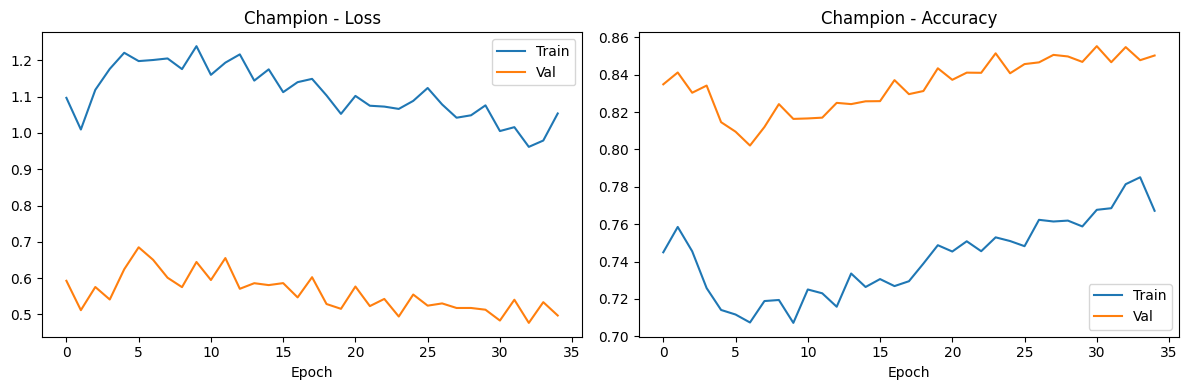

In [12]:
def train_champion(model, epochs, lr, weight_decay, max_lr):
    model = model.to(DEVICE)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.OneCycleLR(
        opt, max_lr=max_lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.2,
        anneal_strategy='cos'
    )
    val_crit = nn.CrossEntropyLoss()
    hist = {'ta': [], 'va': [], 'tl': [], 'vl': []}
    best_acc, best_state = 0.0, None

    for ep in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for X, y in train_loader:
            X, y     = X.to(DEVICE), y.to(DEVICE)
            X        = augment_batch(X)
            X, y_mix = mixup_batch(X, y)
            opt.zero_grad()
            out  = model(X)
            loss = soft_ce(out, y_mix)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            tl += loss.item() * X.size(0)
            tc += (out.argmax(1) == y).sum().item()
            tt += X.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out  = model(X)
                vl  += val_crit(out, y).item() * X.size(0)
                vc  += (out.argmax(1) == y).sum().item()
                vt  += X.size(0)

        ta, va = tc/tt, vc/vt
        hist['tl'].append(tl/tt); hist['vl'].append(vl/vt)
        hist['ta'].append(ta);    hist['va'].append(va)
        if va > best_acc:
            best_acc   = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == 1:
            print(f'[Champion] Ep {ep:2d}/{epochs}  Train {ta:.4f}  Val {va:.4f}  (best {best_acc:.4f})')

    model.load_state_dict(best_state)
    print(f'\n[Champion] Best Val Acc: {best_acc:.4f}')
    return model, hist, best_acc


CHAMP_EPOCHS = 35
champion, ch, champ_val = train_champion(
    champion,
    epochs=CHAMP_EPOCHS,
    lr=0.01,
    weight_decay=0.0003,
    max_lr=0.05
)
plot_history(ch, 'Champion')
torch.save(champion.state_dict(), 'champion_weights.pth')

In [13]:
def count_params(m): return sum(p.numel() for p in m.parameters())

df = pd.DataFrame({
    'Model':         ['Pancake', 'Tower', 'Champion'],
    'Hidden Layers': [2, 8, 3],
    'Width':         ['1024 flat', '128 flat', '512->256->128'],
    'Parameters':    [count_params(pancake), count_params(tower), count_params(champion)],
    'Epochs':        [PANCAKE_EPOCHS, TOWER_EPOCHS, CHAMP_EPOCHS],
    'Val Accuracy':  [f'{pancake_val:.4f}', f'{tower_val:.4f}', f'{champ_val:.4f}']
})
print(df.to_string(index=False))

   Model  Hidden Layers         Width  Parameters  Epochs Val Accuracy
 Pancake              2     1024 flat     1868815      20       0.7648
   Tower              8      128 flat      220047      25       0.7398
Champion              3 512->256->128      570143      35       0.8552


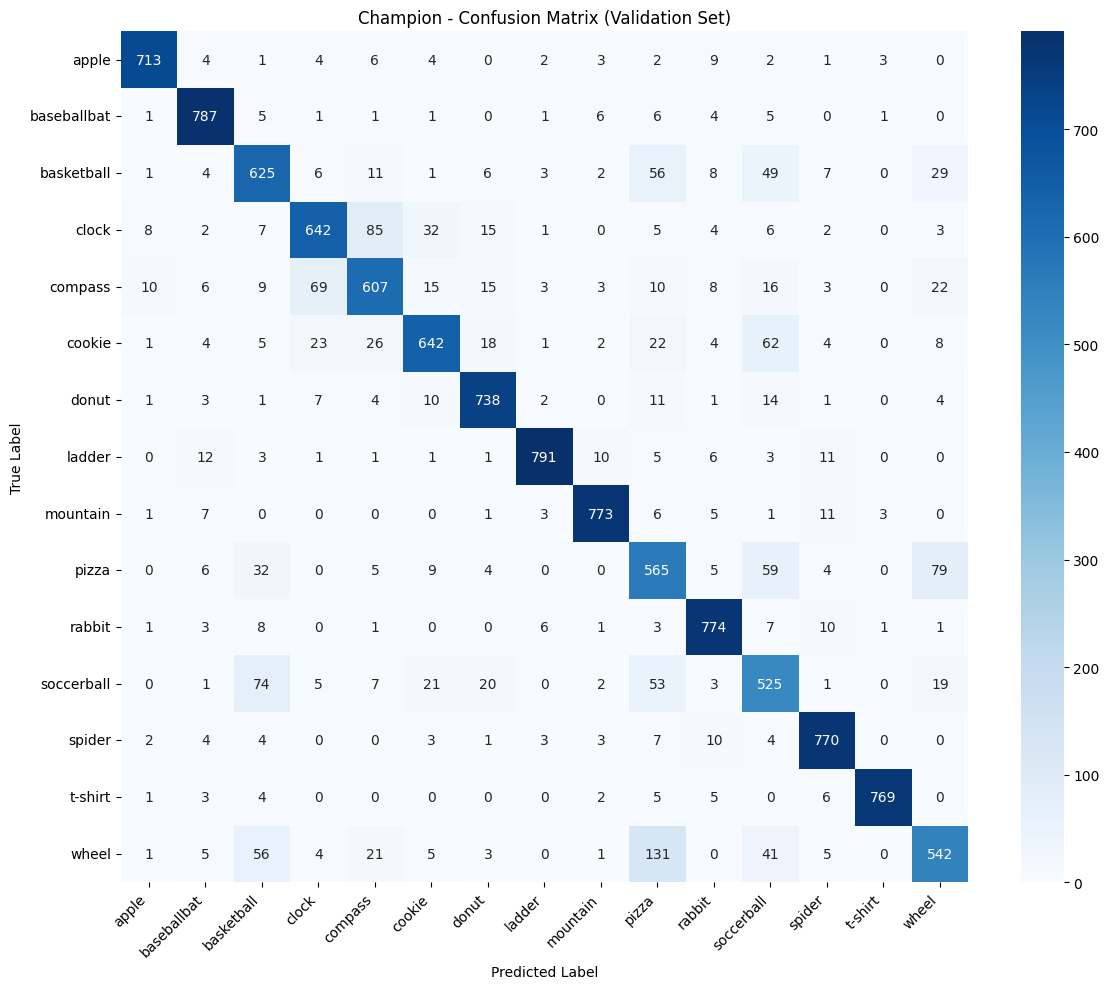

Top confused pairs (true -> predicted):
  wheel        -> pizza       : 131 samples
  clock        -> compass     : 85 samples
  pizza        -> wheel       : 79 samples
  soccerball   -> basketball  : 74 samples
  compass      -> clock       : 69 samples
  cookie       -> soccerball  : 62 samples


In [15]:
champion.eval()
all_p, all_t = [], []
with torch.no_grad():
    for X, y in val_loader:
        all_p.extend(champion(X.to(DEVICE)).argmax(1).cpu().numpy())
        all_t.extend(y.numpy())

cm = confusion_matrix(all_t, all_p)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Champion - Confusion Matrix (Validation Set)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
print('Top confused pairs (true -> predicted):')
for idx in np.argsort(off.flatten())[::-1][:6]:
    r, c = divmod(idx, 15)
    if r != c:
        print(f'  {CLASSES[r]:12s} -> {CLASSES[c]:12s}: {off[r,c]} samples')

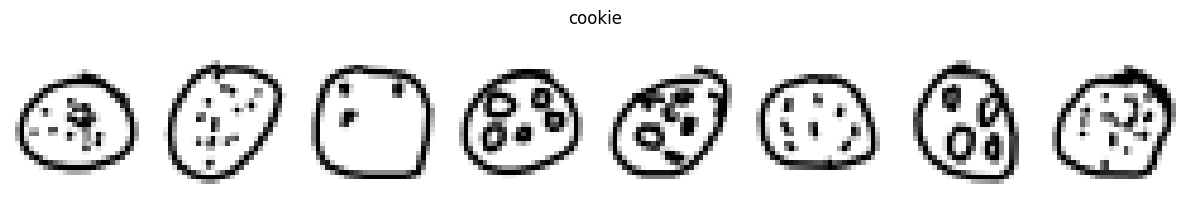

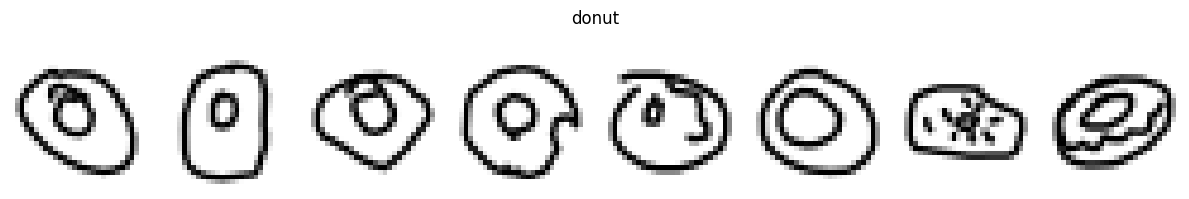

In [16]:
raw = np.load(TRAIN_FILE)
X_all, y_all = raw['x_train'], raw['y_train']

def show_class(cls_idx, n=8):
    idxs = np.where(y_all == cls_idx)[0][:n]
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    for ax, i in zip(axes, idxs):
        ax.imshow(X_all[i].reshape(28, 28), cmap='gray_r'); ax.axis('off')
    fig.suptitle(CLASSES[cls_idx]); plt.tight_layout(); plt.show()

show_class(5)
show_class(6)

In [17]:
test_ds     = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

champion.eval()
preds = []
with torch.no_grad():
    for batch in test_loader:
        preds.extend(champion(batch.to(DEVICE)).argmax(1).cpu().numpy())

with open('submission.txt', 'w') as f:
    f.write(','.join(map(str, preds)))

print(f'Total predictions : {len(preds)}')
print(f'First 20          : {preds[:20]}')
print(f'Parameters        : {count_params(champion):,}')
print(f'Epochs            : {CHAMP_EPOCHS}')

Loaded 15000 test samples
Total predictions : 15000
First 20          : [np.int64(6), np.int64(11), np.int64(5), np.int64(6), np.int64(0), np.int64(1), np.int64(11), np.int64(9), np.int64(14), np.int64(8), np.int64(9), np.int64(7), np.int64(11), np.int64(11), np.int64(13), np.int64(8), np.int64(13), np.int64(12), np.int64(11), np.int64(5)]
Parameters        : 570,143
Epochs            : 35
